# Convex Hull Under Orthgonal Transformation

(CVXPY) Apr 28 08:36:46 PM: Encountered unexpected exception importing solver DIFFCP:
ImportError('diffcp >= 1.0.15 is required')
[0.5 0.5 0. ]
[0.5 0.5 0. ]
[ 1. -1.]


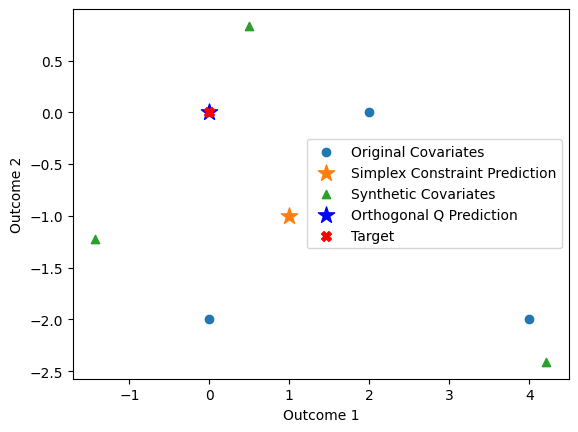

In [1]:
import torch
torch.manual_seed(215)
import matplotlib.pyplot as plt
import cvxpy as cp
import numpy as np
np.random.seed(42)
from learnQorthogonal import learnQorthogonal

# Target and Covariates
d_1 = torch.tensor([0.0,                        # each row represents 
                    0.0], dtype=torch.float64)  # a different outcome

                    # columns represent donors 
Y_1 = torch.tensor([[2.0, 0.0 ,4],
                    [0.0, -2.0,-2]], dtype=torch.float64)
targets = [d_1]
covariates = [Y_1]

# LearnQ optimization
Q_final, w_final = learnQorthogonal(targets, covariates, embedding_dim=3, n_iterations=1000,
                           reg_Q=0, reg_w=0, verbose=False, num_timepoints = 1, init_Q = "eye", fixed_weights=False)

# Optimization over the simplex
target = d_1
covariates = Y_1

# Convert to numpy for cvxpy
target_np   = target.numpy()       # Fix 1: cvxpy needs numpy, not torch tensors
cov_np      = covariates.numpy()   # Fix 1: same here

N = covariates.shape[1]
w = cp.Variable(N, nonneg=True)
constraints = [cp.sum(w) == 1]
obj = cp.Minimize(cp.sum_squares(target_np - cov_np @ w))  # Fix 1 & 2
prob = cp.Problem(obj, constraints)
prob.solve()
print(w.value)


print(w.value)

# Results
synth_covariates = (covariates @ Q_final).squeeze().numpy()
simplex_constraint_pred = (covariates @ w.value).detach().numpy().round(3)
print(simplex_constraint_pred)
learnQ_pred = (covariates @ Q_final @ w_final).squeeze().numpy()

# Plot
plt.scatter(Y_1[0, :],  Y_1[1, :],  label='Original Covariates')
plt.scatter(simplex_constraint_pred[0], simplex_constraint_pred[1],
            label='Simplex Constraint Prediction', marker='*', s=150)
plt.scatter(synth_covariates[0, :], synth_covariates[1, :],    
            label='Synthetic Covariates', marker='^')
plt.scatter(learnQ_pred[0], learnQ_pred[1],
            label='Orthogonal Q Prediction', color="blue", marker='*', s=150)
plt.scatter(target[0].item(), target[1].item(),
            color='red', label='Target', marker='X', s=50)

plt.xlabel('Outcome 1')
plt.ylabel('Outcome 2')
plt.legend()
plt.grid(False)
plt.show() 